In [1]:
!pip install -q kaggle timm h5py scikit-learn

In [1]:
import os, glob, h5py, warnings
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import timm
import matplotlib.pyplot as plt

from google.colab import files
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
from sklearn.metrics import precision_recall_curve, average_precision_score

warnings.filterwarnings("ignore")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

!nvidia-smi

CLASS_NAMES = ["NCR", "ED", "ET"]

Device: cuda
Tue Apr 28 19:58:20 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   33C    P0             43W /  400W |       6MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+----------------------------------

In [2]:
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"gautamighadiyaram","key":"e90b291292b9c0d61aabcffbde431d0c"}'}

In [3]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!mkdir -p /content/brats2020
!kaggle datasets download -d awsaf49/brats2020-training-data -p /content/brats2020 --unzip

Dataset URL: https://www.kaggle.com/datasets/awsaf49/brats2020-training-data
License(s): CC0-1.0
100% 6.76G/6.76G [07:25<00:00, 16.3MB/s]



In [4]:
ROOT = "/content/brats2020"

csv_files = glob.glob(ROOT + "/**/*.csv", recursive=True)
h5_files = glob.glob(ROOT + "/**/*.h5", recursive=True)

print("CSV files:", csv_files)
print("Number of h5 files:", len(h5_files))

CSV_PATH = csv_files[0]
H5_DIR = os.path.dirname(h5_files[0])

print("Using CSV:", CSV_PATH)
print("Using H5 folder:", H5_DIR)

CSV files: ['/content/brats2020/BraTS20 Training Metadata.csv', '/content/brats2020/BraTS2020_training_data/content/data/meta_data.csv', '/content/brats2020/BraTS2020_training_data/content/data/name_mapping.csv', '/content/brats2020/BraTS2020_training_data/content/data/survival_info.csv']
Number of h5 files: 57195
Using CSV: /content/brats2020/BraTS20 Training Metadata.csv
Using H5 folder: /content/brats2020/BraTS2020_training_data/content/data


In [5]:
meta = pd.read_csv(CSV_PATH)

print(meta.shape)
print(meta.head())
print(meta.columns)

(57195, 8)
                                          slice_path  target  volume  slice  \
0  ../input/brats2020-training-data/BraTS2020_tra...       0      41      0   
1  ../input/brats2020-training-data/BraTS2020_tra...       0      41      1   
2  ../input/brats2020-training-data/BraTS2020_tra...       0      41      2   
3  ../input/brats2020-training-data/BraTS2020_tra...       0      41      3   
4  ../input/brats2020-training-data/BraTS2020_tra...       0      41      4   

   label0_pxl_cnt  label1_pxl_cnt  label2_pxl_cnt  background_ratio  
0               0               0               0               1.0  
1               0               0               0               1.0  
2               0               0               0               1.0  
3               0               0               0               1.0  
4               0               0               0               1.0  
Index(['slice_path', 'target', 'volume', 'slice', 'label0_pxl_cnt',
       'label1_pxl_cnt', '

In [6]:
patient_data = {}

for _, row in meta.iterrows():
    pid = row["volume"]
    fname = os.path.basename(row["slice_path"])

    if pid not in patient_data:
        patient_data[pid] = {
            "files": [],
            "label": np.zeros(3, dtype=np.float32)
        }

    patient_data[pid]["files"].append(fname)

    # Correct mapping based on your CSV columns
    # label0_pxl_cnt -> NCR
    # label1_pxl_cnt -> ED
    # label2_pxl_cnt -> ET
    if row["label0_pxl_cnt"] > 0:
        patient_data[pid]["label"][0] = 1

    if row["label1_pxl_cnt"] > 0:
        patient_data[pid]["label"][1] = 1

    if row["label2_pxl_cnt"] > 0:
        patient_data[pid]["label"][2] = 1


patients = np.array(list(patient_data.keys()))
labels = np.array([patient_data[p]["label"] for p in patients], dtype=np.float32)

print("Total patients:", len(patients))
print("Label sums [NCR, ED, ET]:", labels.sum(axis=0))
print("First 10 labels:")
print(labels[:10])

Total patients: 369
Label sums [NCR, ED, ET]: [368. 368. 342.]
First 10 labels:
[[1. 1. 1.]
 [1. 1. 1.]
 [1. 1. 1.]
 [1. 1. 0.]
 [1. 1. 1.]
 [1. 1. 1.]
 [1. 1. 1.]
 [1. 1. 0.]
 [1. 1. 1.]
 [1. 1. 1.]]


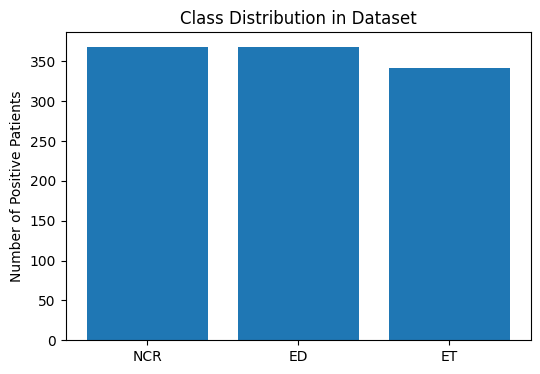

In [7]:
plt.figure(figsize=(6,4))
plt.bar(CLASS_NAMES, labels.sum(axis=0))
plt.ylabel("Number of Positive Patients")
plt.title("Class Distribution in Dataset")
plt.show()

In [8]:
train_p, temp_p, train_y, temp_y = train_test_split(
    patients,
    labels,
    test_size=0.30,
    random_state=42,
    shuffle=True
)

val_p, test_p, val_y, test_y = train_test_split(
    temp_p,
    temp_y,
    test_size=0.50,
    random_state=42,
    shuffle=True
)

print("Train:", len(train_p))
print("Val:", len(val_p))
print("Test:", len(test_p))

Train: 258
Val: 55
Test: 56


In [9]:
class BraTSPatientSequenceDataset(Dataset):
    def __init__(self, patient_ids, labels, patient_data, h5_dir, num_slices=155):
        self.patient_ids = patient_ids
        self.labels = labels
        self.patient_data = patient_data
        self.h5_dir = h5_dir
        self.num_slices = num_slices

    def __len__(self):
        return len(self.patient_ids)

    def choose_slices(self, files):
        files = sorted(files)
        total = len(files)

        if total >= self.num_slices:
            idx = np.linspace(0, total - 1, self.num_slices).astype(int)
            return [files[i] for i in idx]

        selected = files.copy()
        while len(selected) < self.num_slices:
            selected.append(files[-1])

        return selected

    def normalize(self, img):
        img = img.astype(np.float32)

        for c in range(img.shape[-1]):
            ch = img[:, :, c]
            img[:, :, c] = (ch - ch.mean()) / (ch.std() + 1e-6)

        return img

    def __getitem__(self, idx):
        pid = self.patient_ids[idx]
        label = torch.tensor(self.labels[idx], dtype=torch.float32)

        files = self.patient_data[pid]["files"]
        selected_files = self.choose_slices(files)

        volume_slices = []

        for fname in selected_files:
            path = os.path.join(self.h5_dir, fname)

            with h5py.File(path, "r") as f:
                img = f["image"][()]

            img = self.normalize(img)
            img = np.transpose(img, (2, 0, 1))

            img = torch.tensor(img, dtype=torch.float32)

            img = F.interpolate(
                img.unsqueeze(0),
                size=(224, 224),
                mode="bilinear",
                align_corners=False
            ).squeeze(0)

            volume_slices.append(img)

        volume = torch.stack(volume_slices)

        return volume, label

In [10]:
NUM_SLICES = 155
BATCH_SIZE = 1

train_ds = BraTSPatientSequenceDataset(train_p, train_y, patient_data, H5_DIR, NUM_SLICES)
val_ds   = BraTSPatientSequenceDataset(val_p, val_y, patient_data, H5_DIR, NUM_SLICES)
test_ds  = BraTSPatientSequenceDataset(test_p, test_y, patient_data, H5_DIR, NUM_SLICES)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

x, y = next(iter(train_loader))
print("Input shape:", x.shape)
print("Label shape:", y.shape)
print("Sample label:", y)

Input shape: torch.Size([1, 155, 4, 224, 224])
Label shape: torch.Size([1, 3])
Sample label: tensor([[0., 1., 1.]])


In [11]:
class SwinTemporalTransformer(nn.Module):
    def __init__(
        self,
        num_classes=3,
        num_slices=155,
        hidden_dim=768,
        num_heads=8,
        num_layers=4,
        dropout=0.3
    ):
        super().__init__()

        self.swin = timm.create_model(
            "swin_tiny_patch4_window7_224",
            pretrained=True,
            in_chans=4,
            num_classes=0,
            global_pool="avg"
        )

        swin_dim = self.swin.num_features

        self.feature_projection = nn.Linear(swin_dim, hidden_dim)

        self.pos_embedding = nn.Parameter(
            torch.randn(1, num_slices, hidden_dim)
        )

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=hidden_dim,
            nhead=num_heads,
            dim_feedforward=hidden_dim * 4,
            dropout=dropout,
            activation="gelu",
            batch_first=True
        )

        self.temporal_transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers
        )

        self.classifier = nn.Sequential(
            nn.LayerNorm(hidden_dim),
            nn.Linear(hidden_dim, 256),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        B, T, C, H, W = x.shape

        x = x.reshape(B * T, C, H, W)

        slice_features = self.swin(x)
        slice_features = self.feature_projection(slice_features)

        slice_features = slice_features.reshape(B, T, -1)

        slice_features = slice_features + self.pos_embedding[:, :T, :]

        temporal_features = self.temporal_transformer(slice_features)

        patient_feature = temporal_features.mean(dim=1)

        logits = self.classifier(patient_feature)

        return logits

In [12]:
model = SwinTemporalTransformer(
    num_classes=3,
    num_slices=NUM_SLICES,
    hidden_dim=768,
    num_heads=8,
    num_layers=4,
    dropout=0.3
).to(DEVICE)

print("Model ready")

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Total parameters:", total_params)
print("Trainable parameters:", trainable_params)

model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

Model ready
Total parameters: 56781181
Trainable parameters: 56781181


In [13]:
label_counts = train_y.sum(axis=0)
total_train = len(train_y)

pos_weights = (total_train - label_counts) / (label_counts + 1e-6)
pos_weights = torch.tensor(pos_weights, dtype=torch.float32).to(DEVICE)

print("Positive weights:", pos_weights)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weights)

optimizer = torch.optim.AdamW([
    {"params": model.swin.parameters(), "lr": 1e-5},
    {"params": model.feature_projection.parameters(), "lr": 1e-4},
    {"params": model.temporal_transformer.parameters(), "lr": 5e-5},
    {"params": model.classifier.parameters(), "lr": 1e-4},
    {"params": [model.pos_embedding], "lr": 1e-4},
], weight_decay=1e-4)

EPOCHS = 30
PATIENCE = 7

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=EPOCHS
)

scaler = torch.cuda.amp.GradScaler()

Positive weights: tensor([0.0039, 0.0039, 0.0795], device='cuda:0')


In [14]:
BEST_PATH = "/content/swint_temporal_155_best_FIXED.pt"

best_val_loss = float("inf")
wait = 0

train_losses = []
val_losses = []

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0

    for images, targets in train_loader:
        images = images.to(DEVICE)
        targets = targets.to(DEVICE)

        optimizer.zero_grad()

        with torch.cuda.amp.autocast():
            logits = model(images)
            loss = criterion(logits, targets)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        train_loss += loss.item()

    avg_train_loss = train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    model.eval()
    val_loss = 0

    with torch.no_grad():
        for images, targets in val_loader:
            images = images.to(DEVICE)
            targets = targets.to(DEVICE)

            with torch.cuda.amp.autocast():
                logits = model(images)
                loss = criterion(logits, targets)

            val_loss += loss.item()

    avg_val_loss = val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    scheduler.step()

    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss: {avg_train_loss:.4f}")
    print(f"Val Loss:   {avg_val_loss:.4f}")

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        wait = 0
        torch.save(model.state_dict(), BEST_PATH)
        print("Best model saved")
    else:
        wait += 1
        print("No improvement:", wait)

        if wait >= PATIENCE:
            print("Early stopping")
            break

    print("-" * 40)

Epoch 1/30
Train Loss: 0.0589
Val Loss:   0.0383
Best model saved
----------------------------------------
Epoch 2/30
Train Loss: 0.0421
Val Loss:   0.0395
No improvement: 1
----------------------------------------
Epoch 3/30
Train Loss: 0.0406
Val Loss:   0.0388
No improvement: 2
----------------------------------------
Epoch 4/30
Train Loss: 0.0403
Val Loss:   0.0384
No improvement: 3
----------------------------------------
Epoch 5/30
Train Loss: 0.0437
Val Loss:   0.0390
No improvement: 4
----------------------------------------
Epoch 6/30
Train Loss: 0.0401
Val Loss:   0.0408
No improvement: 5
----------------------------------------
Epoch 7/30
Train Loss: 0.0397
Val Loss:   0.0391
No improvement: 6
----------------------------------------
Epoch 8/30
Train Loss: 0.0385
Val Loss:   0.0389
No improvement: 7
Early stopping


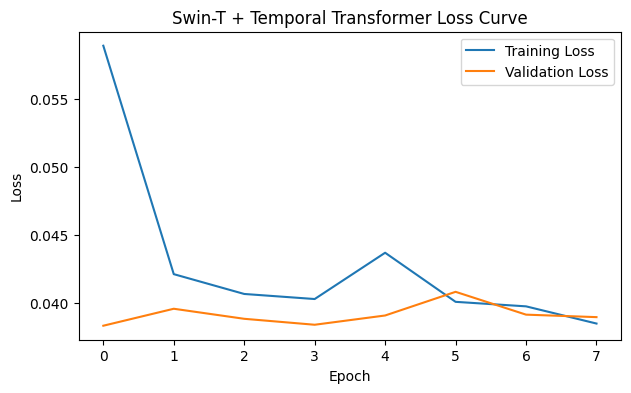

In [15]:
plt.figure(figsize=(7,4))
plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Swin-T + Temporal Transformer Loss Curve")
plt.legend()
plt.show()

In [16]:
model.load_state_dict(torch.load(BEST_PATH, map_location=DEVICE))
model.eval()

all_probs = []
all_preds = []
all_targets = []

with torch.no_grad():
    for images, targets in test_loader:
        images = images.to(DEVICE)

        with torch.cuda.amp.autocast():
            logits = model(images)

        probs = torch.sigmoid(logits).cpu().numpy()
        preds = (probs >= 0.5).astype(int)

        all_probs.append(probs[0])
        all_preds.append(preds[0])
        all_targets.append(targets.numpy()[0])

all_probs = np.array(all_probs)
all_preds = np.array(all_preds)
all_targets = np.array(all_targets)

print("Targets shape:", all_targets.shape)
print("Predictions shape:", all_preds.shape)
print("Target sums in test:", all_targets.sum(axis=0))
print("Prediction sums in test:", all_preds.sum(axis=0))

Targets shape: (56, 3)
Predictions shape: (56, 3)
Target sums in test: [56. 56. 53.]
Prediction sums in test: [56 56  0]


In [17]:
print("=" * 60)
print("FINAL RESULTS: Swin-T + Temporal Transformer")
print("=" * 60)

for i, cls in enumerate(CLASS_NAMES):
    print(f"\nClass: {cls}")
    print(classification_report(
        all_targets[:, i],
        all_preds[:, i],
        labels=[0, 1],
        target_names=[f"No {cls}", cls],
        zero_division=0
    ))

flat_accuracy = accuracy_score(all_targets.flatten(), all_preds.flatten())
macro_f1 = f1_score(all_targets, all_preds, average="macro", zero_division=0)
micro_f1 = f1_score(all_targets, all_preds, average="micro", zero_division=0)

print("\nOverall Metrics")
print("Flat Accuracy:", flat_accuracy)
print("Macro F1:", macro_f1)
print("Micro F1:", micro_f1)

print("\nAUROC Scores")
for i, cls in enumerate(CLASS_NAMES):
    if len(np.unique(all_targets[:, i])) < 2:
        print(f"{cls}: AUROC not available because test set has only one class")
    else:
        auc_score = roc_auc_score(all_targets[:, i], all_probs[:, i])
        print(f"{cls}: {auc_score:.4f}")

FINAL RESULTS: Swin-T + Temporal Transformer

Class: NCR
              precision    recall  f1-score   support

      No NCR       0.00      0.00      0.00         0
         NCR       1.00      1.00      1.00        56

    accuracy                           1.00        56
   macro avg       0.50      0.50      0.50        56
weighted avg       1.00      1.00      1.00        56


Class: ED
              precision    recall  f1-score   support

       No ED       0.00      0.00      0.00         0
          ED       1.00      1.00      1.00        56

    accuracy                           1.00        56
   macro avg       0.50      0.50      0.50        56
weighted avg       1.00      1.00      1.00        56


Class: ET
              precision    recall  f1-score   support

       No ET       0.05      1.00      0.10         3
          ET       0.00      0.00      0.00        53

    accuracy                           0.05        56
   macro avg       0.03      0.50      0.05      

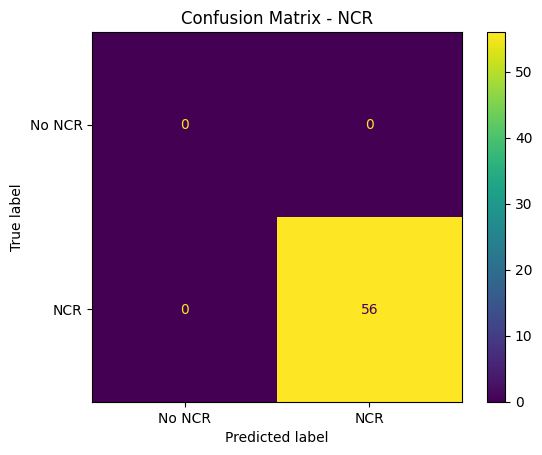

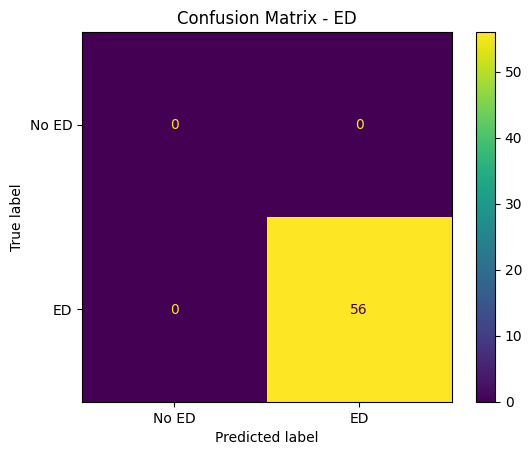

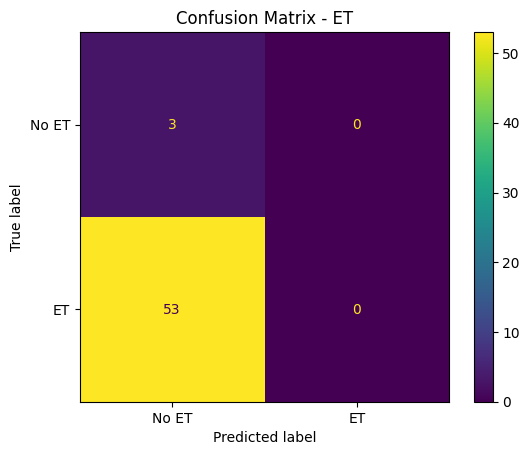

In [18]:
for i, cls in enumerate(CLASS_NAMES):
    cm = confusion_matrix(all_targets[:, i], all_preds[:, i], labels=[0, 1])
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=[f"No {cls}", cls]
    )
    disp.plot()
    plt.title(f"Confusion Matrix - {cls}")
    plt.show()

NCR: ROC curve not available because test set has only one class
ED: ROC curve not available because test set has only one class


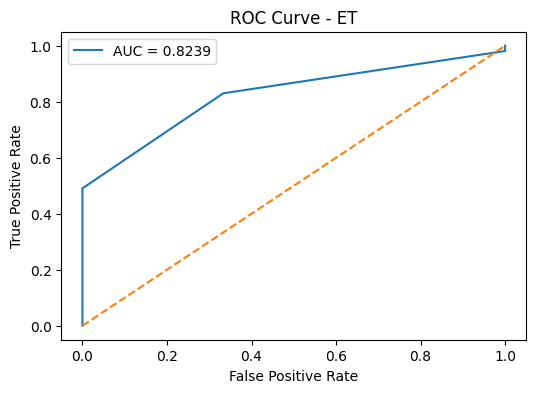

In [19]:
for i, cls in enumerate(CLASS_NAMES):
    if len(np.unique(all_targets[:, i])) < 2:
        print(f"{cls}: ROC curve not available because test set has only one class")
        continue

    fpr, tpr, _ = roc_curve(all_targets[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(6,4))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve - {cls}")
    plt.legend()
    plt.show()

NCR: PR curve not available because test set has only one class
ED: PR curve not available because test set has only one class


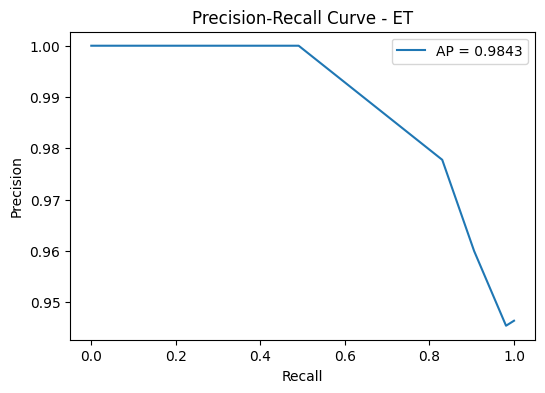

In [20]:
for i, cls in enumerate(CLASS_NAMES):
    if len(np.unique(all_targets[:, i])) < 2:
        print(f"{cls}: PR curve not available because test set has only one class")
        continue

    precision, recall, _ = precision_recall_curve(all_targets[:, i], all_probs[:, i])
    ap = average_precision_score(all_targets[:, i], all_probs[:, i])

    plt.figure(figsize=(6,4))
    plt.plot(recall, precision, label=f"AP = {ap:.4f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"Precision-Recall Curve - {cls}")
    plt.legend()
    plt.show()

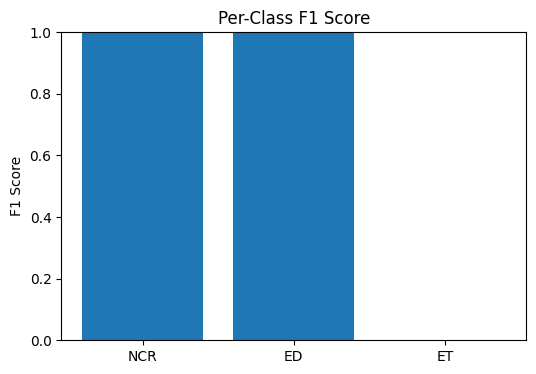

In [21]:
f1_values = []

for i, cls in enumerate(CLASS_NAMES):
    f1 = f1_score(all_targets[:, i], all_preds[:, i], zero_division=0)
    f1_values.append(f1)

plt.figure(figsize=(6,4))
plt.bar(CLASS_NAMES, f1_values)
plt.ylim(0, 1)
plt.ylabel("F1 Score")
plt.title("Per-Class F1 Score")
plt.show()

Showing patient: 0 Label: [1. 1. 1.]


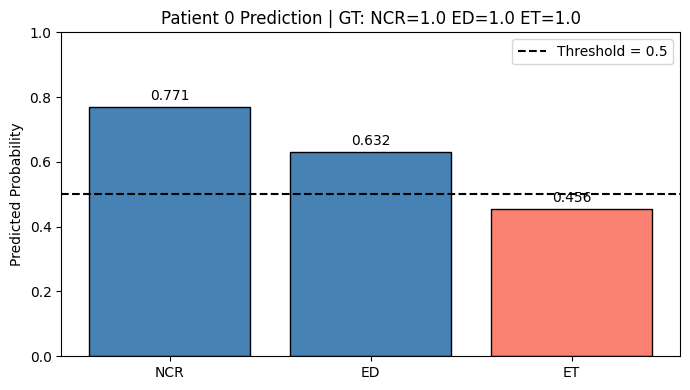

In [22]:
@torch.no_grad()
def visualize_patient_prediction(model, dataset, idx, device):
    model.eval()

    vol, gt = dataset[idx]
    vol = vol.unsqueeze(0).to(device)

    with torch.cuda.amp.autocast():
        logits = model(vol)

    probs = torch.sigmoid(logits).squeeze().cpu().numpy()
    gt = gt.numpy()

    plt.figure(figsize=(7, 4))

    colors = ["steelblue" if p >= 0.5 else "salmon" for p in probs]

    bars = plt.bar(CLASS_NAMES, probs, color=colors, edgecolor="black")
    plt.axhline(0.5, color="black", linestyle="--", label="Threshold = 0.5")

    plt.ylim(0, 1)
    plt.ylabel("Predicted Probability")
    plt.title(f"Patient {idx} Prediction | GT: NCR={gt[0]} ED={gt[1]} ET={gt[2]}")

    for b, p in zip(bars, probs):
        plt.text(
            b.get_x() + b.get_width()/2,
            p + 0.02,
            f"{p:.3f}",
            ha="center"
        )

    plt.legend()
    plt.tight_layout()
    plt.show()


for i in range(len(test_ds)):
    _, label = test_ds[i]
    if label.sum() > 0:
        print("Showing patient:", i, "Label:", label.numpy())
        visualize_patient_prediction(model, test_ds, i, DEVICE)
        break

In [23]:
output_df = pd.DataFrame({
    "patient_id": test_p,
    "true_NCR": all_targets[:, 0],
    "true_ED": all_targets[:, 1],
    "true_ET": all_targets[:, 2],
    "prob_NCR": all_probs[:, 0],
    "prob_ED": all_probs[:, 1],
    "prob_ET": all_probs[:, 2],
    "pred_NCR": all_preds[:, 0],
    "pred_ED": all_preds[:, 1],
    "pred_ET": all_preds[:, 2],
})

output_path = "/content/swint_temporal_FIXED_predictions.csv"
output_df.to_csv(output_path, index=False)

print("Saved:", output_path)
output_df.head()

Saved: /content/swint_temporal_FIXED_predictions.csv


,patient_id,true_NCR,true_ED,true_ET,prob_NCR,prob_ED,prob_ET,pred_NCR,pred_ED,pred_ET
0,290,1.0,1.0,1.0,0.770508,0.631836,0.455566,1,1,0
1,127,1.0,1.0,1.0,0.769043,0.631836,0.455078,1,1,0
2,37,1.0,1.0,1.0,0.769043,0.632324,0.455078,1,1,0
3,20,1.0,1.0,1.0,0.770020,0.632812,0.455811,1,1,0
4,184,1.0,1.0,1.0,0.769531,0.632324,0.455322,1,1,0


In [24]:
import json
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, log_loss

thresholds = {
    "NCR": 0.5,
    "ED": 0.5,
    "ET": 0.5
}

results = {
    "model": "Swin-T + Temporal Transformer",
    "thresholds": thresholds,
    "accuracy": float(flat_accuracy),
    "macro_f1": float(macro_f1),
    "micro_f1": float(micro_f1),
    "auroc": {},
    "log_loss": {},
    "per_class": {},
    "all_probs": all_probs.tolist(),
    "all_preds": all_preds.astype(float).tolist(),
    "all_labels": all_targets.astype(float).tolist()
}

for i, cls in enumerate(CLASS_NAMES):
    y_true = all_targets[:, i]
    y_prob = all_probs[:, i]
    y_pred = all_preds[:, i]

    results["per_class"][cls] = {
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0))
    }

    if len(np.unique(y_true)) >= 2:
        results["auroc"][cls] = float(roc_auc_score(y_true, y_prob))
        results["log_loss"][cls] = float(log_loss(y_true, y_prob, labels=[0, 1]))
    else:
        results["auroc"][cls] = None
        results["log_loss"][cls] = None

valid_aurocs = [v for v in results["auroc"].values() if v is not None]
results["macro_auroc"] = float(np.mean(valid_aurocs)) if len(valid_aurocs) > 0 else None

valid_log_losses = [v for v in results["log_loss"].values() if v is not None]
results["mean_log_loss"] = float(np.mean(valid_log_losses)) if len(valid_log_losses) > 0 else None

json_path = "/content/swint_temporal_results.json"

with open(json_path, "w") as f:
    json.dump(results, f, indent=4)

print("Saved JSON results to:", json_path)

Saved JSON results to: /content/swint_temporal_results.json
